In [10]:
# ============================================================================
# ПОДГОТОВИТЕЛЬНАЯ ЧАСТЬ: Импорт библиотек и настройка
# 准备部分：导入库和设置
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

%matplotlib inline

# Настройка стиля графиков (только английский + русский)
# 设置图表样式（只用英文+俄语）
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.unicode_minus'] = False

print("=" * 60)
print("БИБЛИОТЕКИ УСПЕШНО ЗАГРУЖЕНЫ")
print("所有库已成功加载")
print("=" * 60)

БИБЛИОТЕКИ УСПЕШНО ЗАГРУЖЕНЫ
所有库已成功加载


In [11]:
# ============================================================================
# ЗАГРУЗКА ДАТАСЕТА: Titanic
# 加载数据集：泰坦尼克号
# ============================================================================

df = sns.load_dataset('titanic')

print("=" * 60)
print("ИНФОРМАЦИЯ О ДАТАСЕТЕ TITANIC")
print("泰坦尼克号数据集信息")
print("=" * 60)

print(f"\nРазмер датасета / 数据集大小: {df.shape[0]} строк × {df.shape[1]} столбцов")

print("\n" + "-" * 60)
print("ПЕРВЫЕ 5 СТРОК / 前5行数据")
print("-" * 60)
df.head()

ИНФОРМАЦИЯ О ДАТАСЕТЕ TITANIC
泰坦尼克号数据集信息

Размер датасета / 数据集大小: 891 строк × 15 столбцов

------------------------------------------------------------
ПЕРВЫЕ 5 СТРОК / 前5行数据
------------------------------------------------------------


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
# ============================================================================
# АНАЛИЗ ПРОПУСКОВ В ДАННЫХ
# 分析数据中的缺失值
# ============================================================================

print("=" * 60)
print("АНАЛИЗ ПРОПУСКОВ В ДАННЫХ")
print("数据缺失值分析")
print("=" * 60)

missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Пропуски / 缺失数': missing_count,
    'Процент / 百分比 (%)': missing_percent
})
missing_df = missing_df[missing_df['Пропуски / 缺失数'] > 0].sort_values('Процент / 百分比 (%)', ascending=False)

print("\nСТОЛБЦЫ С ПРОПУСКАМИ / 包含缺失值的列:")
print(missing_df)

print("\n" + "-" * 60)
print("ТИПЫ ДАННЫХ / 数据类型:")
print("-" * 60)
print(df.dtypes)

АНАЛИЗ ПРОПУСКОВ В ДАННЫХ
数据缺失值分析

СТОЛБЦЫ С ПРОПУСКАМИ / 包含缺失值的列:
             Пропуски / 缺失数  Процент / 百分比 (%)
deck                    688          77.216611
age                     177          19.865320
embarked                  2           0.224467
embark_town               2           0.224467

------------------------------------------------------------
ТИПЫ ДАННЫХ / 数据类型:
------------------------------------------------------------
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


ЗАДАЧА 1: ОБРАБОТКА ПРОПУСКОВ
TASK 1: HANDLING MISSING VALUES

【1.1】ПРОПУСКИ ДО ОБРАБОТКИ / MISSING VALUES BEFORE:
  - age: 177 missing (19.9%)
  - deck: 688 missing (77.2%)
  - embarked: 2 missing (0.2%)
  - embark_town: 2 missing (0.2%)

------------------------------------------------------------
【1.2】ЧИСЛОВОЙ ПРИЗНАК: AGE (Numerical feature)
------------------------------------------------------------
  Медиана / Median: 28.0
  ✓ Заполнено медианой / Filled with median: 177 → 0


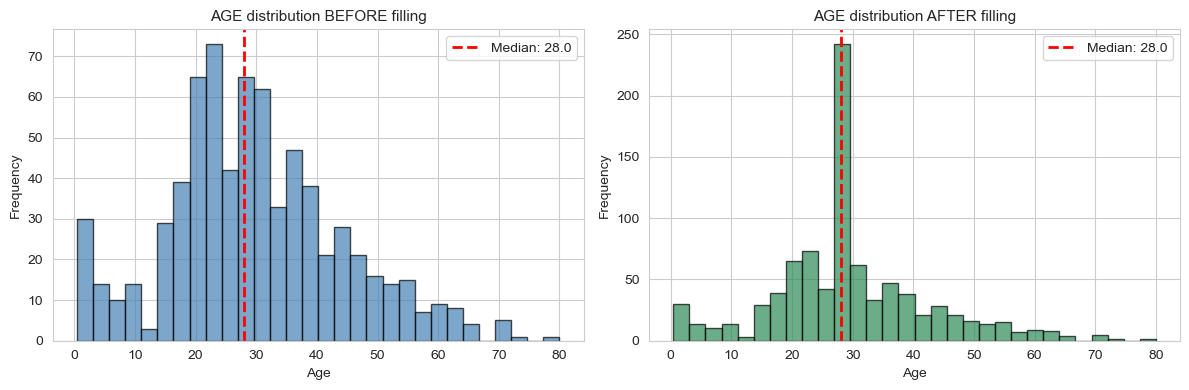


------------------------------------------------------------
【1.3】КАТЕГОРИАЛЬНЫЙ ПРИЗНАК: EMBARKED (Categorical feature)
------------------------------------------------------------
  Мода / Mode: 'S'
  ✓ Заполнено модой / Filled with mode: 2 → 0

------------------------------------------------------------
【1.4】КАТЕГОРИАЛЬНЫЙ ПРИЗНАК: EMBARK_TOWN (Categorical feature)
------------------------------------------------------------
  Мода / Mode: 'Southampton'
  ✓ Заполнено модой / Filled with mode: 2 → 0

------------------------------------------------------------
【1.5】КАТЕГОРИАЛЬНЫЙ ПРИЗНАК: DECK (Categorical feature)
------------------------------------------------------------
  Исходные пропуски / Original missing: 688 (77.2%)
  ✓ Заполнено категорией 'Unknown' / Filled with 'Unknown': no missing values

ИТОГИ ОБРАБОТКИ ПРОПУСКОВ / MISSING VALUES SUMMARY

  Признак / Feature       | До / Before | После / After
  ---------------------------------------------
  age                    

In [13]:
# ============================================================================
# ЗАДАЧА 1: УСТРАНЕНИЕ ПРОПУСКОВ В ДАННЫХ
# TASK 1: HANDLING MISSING VALUES
# ============================================================================

print("=" * 60)
print("ЗАДАЧА 1: ОБРАБОТКА ПРОПУСКОВ")
print("TASK 1: HANDLING MISSING VALUES")
print("=" * 60)

# Создаем копию датасета
# 创建数据集的副本
df_cleaned = df.copy()

print("\n【1.1】ПРОПУСКИ ДО ОБРАБОТКИ / MISSING VALUES BEFORE:")
print(f"  - age: {df_cleaned['age'].isnull().sum()} missing ({df_cleaned['age'].isnull().sum()/len(df)*100:.1f}%)")
print(f"  - deck: {df_cleaned['deck'].isnull().sum()} missing ({df_cleaned['deck'].isnull().sum()/len(df)*100:.1f}%)")
print(f"  - embarked: {df_cleaned['embarked'].isnull().sum()} missing ({df_cleaned['embarked'].isnull().sum()/len(df)*100:.1f}%)")
print(f"  - embark_town: {df_cleaned['embark_town'].isnull().sum()} missing ({df_cleaned['embark_town'].isnull().sum()/len(df)*100:.1f}%)")

# ============================================================================
# 1.2 Обработка числового признака: AGE / 处理数值特征：年龄
# ============================================================================

print("\n" + "-" * 60)
print("【1.2】ЧИСЛОВОЙ ПРИЗНАК: AGE (Numerical feature)")
print("-" * 60)

median_age = df_cleaned['age'].median()
print(f"  Медиана / Median: {median_age:.1f}")

df_cleaned['age_filled'] = df_cleaned['age'].fillna(median_age)
print(f"  ✓ Заполнено медианой / Filled with median: {df_cleaned['age'].isnull().sum()} → {df_cleaned['age_filled'].isnull().sum()}")

# Визуализация / Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_cleaned['age'].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(median_age, color='red', linestyle='dashed', linewidth=2, label=f'Median: {median_age:.1f}')
axes[0].set_title('AGE distribution BEFORE filling', fontsize=11)
axes[0].set_xlabel('Age', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].legend()

axes[1].hist(df_cleaned['age_filled'], bins=30, color='seagreen', edgecolor='black', alpha=0.7)
axes[1].axvline(median_age, color='red', linestyle='dashed', linewidth=2, label=f'Median: {median_age:.1f}')
axes[1].set_title('AGE distribution AFTER filling', fontsize=11)
axes[1].set_xlabel('Age', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================================================
# 1.3 Обработка категориального признака: EMBARKED / 处理分类特征：登船港口
# ============================================================================

print("\n" + "-" * 60)
print("【1.3】КАТЕГОРИАЛЬНЫЙ ПРИЗНАК: EMBARKED (Categorical feature)")
print("-" * 60)

mode_embarked = df_cleaned['embarked'].mode()[0]
print(f"  Мода / Mode: '{mode_embarked}'")

df_cleaned['embarked_filled'] = df_cleaned['embarked'].fillna(mode_embarked)
print(f"  ✓ Заполнено модой / Filled with mode: {df_cleaned['embarked'].isnull().sum()} → {df_cleaned['embarked_filled'].isnull().sum()}")

# ============================================================================
# 1.4 Обработка категориального признака: EMBARK_TOWN / 处理分类特征：登船城市
# ============================================================================

print("\n" + "-" * 60)
print("【1.4】КАТЕГОРИАЛЬНЫЙ ПРИЗНАК: EMBARK_TOWN (Categorical feature)")
print("-" * 60)

mode_town = df_cleaned['embark_town'].mode()[0]
print(f"  Мода / Mode: '{mode_town}'")

df_cleaned['embark_town_filled'] = df_cleaned['embark_town'].fillna(mode_town)
print(f"  ✓ Заполнено модой / Filled with mode: {df_cleaned['embark_town'].isnull().sum()} → {df_cleaned['embark_town_filled'].isnull().sum()}")

# ============================================================================
# 1.5 Обработка категориального признака: DECK / 处理分类特征：甲板
# ============================================================================

print("\n" + "-" * 60)
print("【1.5】КАТЕГОРИАЛЬНЫЙ ПРИЗНАК: DECK (Categorical feature)")
print("-" * 60)

print(f"  Исходные пропуски / Original missing: {df_cleaned['deck'].isnull().sum()} (77.2%)")

# Преобразуем в строку и заполняем 'Unknown'
# 转换为字符串并用 'Unknown' 填充
df_cleaned['deck_filled'] = df_cleaned['deck'].astype(str).fillna('Unknown')
print(f"  ✓ Заполнено категорией 'Unknown' / Filled with 'Unknown': no missing values")

# ============================================================================
# ИТОГИ ОБРАБОТКИ ПРОПУСКОВ / SUMMARY
# ============================================================================

print("\n" + "=" * 60)
print("ИТОГИ ОБРАБОТКИ ПРОПУСКОВ / MISSING VALUES SUMMARY")
print("=" * 60)

print("\n  Признак / Feature       | До / Before | После / After")
print("  " + "-" * 45)
print(f"  age                     | {df['age'].isnull().sum():>10} | {df_cleaned['age_filled'].isnull().sum():>10}")
print(f"  deck                    | {df['deck'].isnull().sum():>10} | {df_cleaned['deck_filled'].isnull().sum():>10}")
print(f"  embarked                | {df['embarked'].isnull().sum():>10} | {df_cleaned['embarked_filled'].isnull().sum():>10}")
print(f"  embark_town             | {df['embark_town'].isnull().sum():>10} | {df_cleaned['embark_town_filled'].isnull().sum():>10}")

print("\n✓ TASK 1 COMPLETED / ЗАДАЧА 1 ВЫПОЛНЕНА!")

In [14]:
# ============================================================================
# ЗАДАЧА 2: КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
# TASK 2: CATEGORICAL FEATURE ENCODING
# ============================================================================

print("=" * 60)
print("ЗАДАЧА 2: КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("TASK 2: CATEGORICAL FEATURE ENCODING")
print("=" * 60)

print("\nИсходные категориальные признаки / Original categorical features:")
print("  - sex (male/female)")
print("  - class (First/Second/Third)")
print("  - embarked (S/C/Q)")
print("  - deck (A/B/C/D/E/F/G/Unknown)")

# ============================================================================
# 2.1 LABEL ENCODING (для class)
# ============================================================================

print("\n" + "-" * 60)
print("【2.1】LABEL ENCODING (for 'class')")
print("-" * 60)

le = LabelEncoder()
df_cleaned['class_encoded'] = le.fit_transform(df_cleaned['class'])

print("  Mapping / Соответствие:")
for i, class_name in enumerate(le.classes_):
    print(f"    {class_name} -> {i}")

print(f"\n  Example:")
print(f"    Original: {df_cleaned['class'].head(3).tolist()}")
print(f"    Encoded:  {df_cleaned['class_encoded'].head(3).tolist()}")

# ============================================================================
# 2.2 ONE-HOT ENCODING (для sex)
# ============================================================================

print("\n" + "-" * 60)
print("【2.2】ONE-HOT ENCODING (for 'sex')")
print("-" * 60)

sex_onehot = pd.get_dummies(df_cleaned['sex'], prefix='sex', dtype=int)
print(f"  New columns: {sex_onehot.columns.tolist()}")

df_cleaned = pd.concat([df_cleaned, sex_onehot], axis=1)

print(f"  Example:")
print(f"    Original: {df_cleaned['sex'].head(3).tolist()}")
print(f"    Encoded:\n{sex_onehot.head(3)}")

# ============================================================================
# 2.3 ONE-HOT ENCODING (для embarked_filled)
# ============================================================================

print("\n" + "-" * 60)
print("【2.3】ONE-HOT ENCODING (for 'embarked_filled')")
print("-" * 60)

embarked_onehot = pd.get_dummies(df_cleaned['embarked_filled'], prefix='embarked', dtype=int)
print(f"  New columns: {embarked_onehot.columns.tolist()}")

df_cleaned = pd.concat([df_cleaned, embarked_onehot], axis=1)

print(f"  Example:")
print(f"    Original: {df_cleaned['embarked_filled'].head(3).tolist()}")
print(f"    Encoded:\n{embarked_onehot.head(3)}")

# ============================================================================
# 2.4 FREQUENCY ENCODING (для deck_filled)
# ============================================================================

print("\n" + "-" * 60)
print("【2.4】FREQUENCY ENCODING (for 'deck_filled')")
print("-" * 60)

deck_freq = df_cleaned['deck_filled'].value_counts(normalize=True)
df_cleaned['deck_freq_encoded'] = df_cleaned['deck_filled'].map(deck_freq)

print("  Category frequency:")
for deck, freq in list(deck_freq.items())[:8]:
    print(f"    {deck}: {freq:.3f} ({freq*100:.1f}%)")

print(f"\n  Example:")
print(f"    Original: {df_cleaned['deck_filled'].head(3).tolist()}")
print(f"    Encoded:  {df_cleaned['deck_freq_encoded'].head(3).tolist()}")

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "=" * 60)
print("ИТОГИ КОДИРОВАНИЯ / ENCODING SUMMARY")
print("=" * 60)

print("\n  No.  Feature         Method              Result")
print("  " + "-" * 50)
print("  1    class           Label Encoding      Numeric (0,1,2)")
print("  2    sex             One-Hot Encoding    2 new columns")
print("  3    embarked_filled One-Hot Encoding    3 new columns")
print("  4    deck_filled     Frequency Encoding  Frequency values")

print("\n✓ TASK 2 COMPLETED / ЗАДАЧА 2 ВЫПОЛНЕНА!")

ЗАДАЧА 2: КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
TASK 2: CATEGORICAL FEATURE ENCODING

Исходные категориальные признаки / Original categorical features:
  - sex (male/female)
  - class (First/Second/Third)
  - embarked (S/C/Q)
  - deck (A/B/C/D/E/F/G/Unknown)

------------------------------------------------------------
【2.1】LABEL ENCODING (for 'class')
------------------------------------------------------------
  Mapping / Соответствие:
    First -> 0
    Second -> 1
    Third -> 2

  Example:
    Original: ['Third', 'First', 'Third']
    Encoded:  [2, 0, 2]

------------------------------------------------------------
【2.2】ONE-HOT ENCODING (for 'sex')
------------------------------------------------------------
  New columns: ['sex_female', 'sex_male']
  Example:
    Original: ['male', 'female', 'female']
    Encoded:
   sex_female  sex_male
0           0         1
1           1         0
2           1         0

------------------------------------------------------------
【2.3】ONE-HO

ЗАДАЧА 3: НОРМАЛИЗАЦИЯ ЧИСЛОВЫХ ПРИЗНАКОВ
TASK 3: NUMERICAL FEATURE NORMALIZATION

Выбранный признак / Selected feature: 'age_filled' (возраст / age)

------------------------------------------------------------
【3.1】MIN-MAX NORMALIZATION [0, 1]
------------------------------------------------------------
  BEFORE / До:
    min = 0.4, max = 80.0, mean = 29.4
  AFTER / После:
    min = 0.0000, max = 1.0000, mean = 0.3637

------------------------------------------------------------
【3.2】STANDARDIZATION (Z-SCORE)
------------------------------------------------------------
  BEFORE / До:
    mean = 29.36, std = 13.02
  AFTER / После:
    mean = 0.000000, std = 1.000562

------------------------------------------------------------
【3.3】ВИЗУАЛИЗАЦИЯ / VISUALIZATION
------------------------------------------------------------


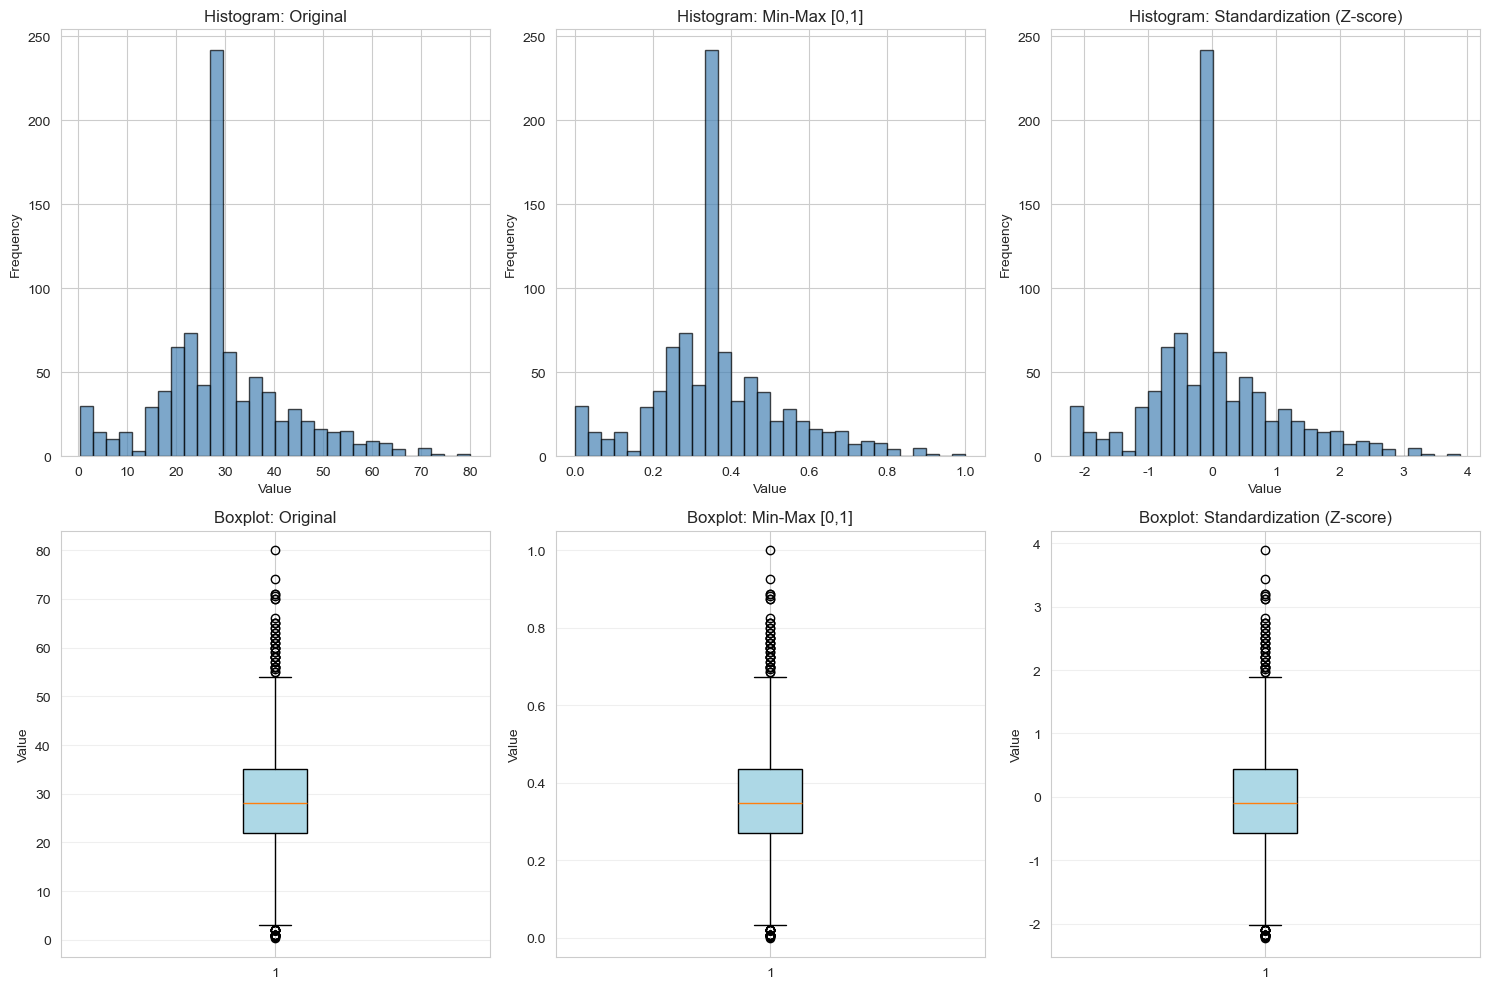


СРАВНЕНИЕ МЕТОДОВ / METHODS COMPARISON
                   Method       Min       Max         Mean       Std
                 Original  0.420000 80.000000 2.936158e+01 13.019697
            Min-Max (0,1)  0.000000  1.000000 3.636791e-01  0.163605
Standardization (Z-score) -2.224156  3.891554 2.272780e-16  1.000562

ОБЩИЙ ИТОГ / FINAL SUMMARY
  ✓ TASK 1: Missing values handled
  ✓ TASK 2: Categorical features encoded
  ✓ TASK 3: Numerical features normalized
  ✓ Задача 1: Пропуски обработаны
  ✓ Задача 2: Категориальные признаки закодированы
  ✓ Задача 3: Числовые признаки нормализованы

🎉 ALL TASKS COMPLETED SUCCESSFULLY!
🎉 ВСЕ ЗАДАЧИ ВЫПОЛНЕНЫ УСПЕШНО!


In [15]:
# ============================================================================
# ЗАДАЧА 3: НОРМАЛИЗАЦИЯ ЧИСЛОВЫХ ПРИЗНАКОВ
# TASK 3: NUMERICAL FEATURE NORMALIZATION
# ============================================================================

print("=" * 60)
print("ЗАДАЧА 3: НОРМАЛИЗАЦИЯ ЧИСЛОВЫХ ПРИЗНАКОВ")
print("TASK 3: NUMERICAL FEATURE NORMALIZATION")
print("=" * 60)

print(f"\nВыбранный признак / Selected feature: 'age_filled' (возраст / age)")

# ============================================================================
# 3.1 MIN-MAX NORMALIZATION [0, 1]
# ============================================================================

print("\n" + "-" * 60)
print("【3.1】MIN-MAX NORMALIZATION [0, 1]")
print("-" * 60)

scaler_minmax = MinMaxScaler()
df_cleaned['age_minmax'] = scaler_minmax.fit_transform(df_cleaned[['age_filled']])

print(f"  BEFORE / До:")
print(f"    min = {df_cleaned['age_filled'].min():.1f}, max = {df_cleaned['age_filled'].max():.1f}, mean = {df_cleaned['age_filled'].mean():.1f}")
print(f"  AFTER / После:")
print(f"    min = {df_cleaned['age_minmax'].min():.4f}, max = {df_cleaned['age_minmax'].max():.4f}, mean = {df_cleaned['age_minmax'].mean():.4f}")

# ============================================================================
# 3.2 STANDARDIZATION (Z-SCORE)
# ============================================================================

print("\n" + "-" * 60)
print("【3.2】STANDARDIZATION (Z-SCORE)")
print("-" * 60)

scaler_std = StandardScaler()
df_cleaned['age_standardized'] = scaler_std.fit_transform(df_cleaned[['age_filled']])

print(f"  BEFORE / До:")
print(f"    mean = {df_cleaned['age_filled'].mean():.2f}, std = {df_cleaned['age_filled'].std():.2f}")
print(f"  AFTER / После:")
print(f"    mean = {df_cleaned['age_standardized'].mean():.6f}, std = {df_cleaned['age_standardized'].std():.6f}")

# ============================================================================
# 3.3 VISUALIZATION (English + Russian only)
# ============================================================================

print("\n" + "-" * 60)
print("【3.3】ВИЗУАЛИЗАЦИЯ / VISUALIZATION")
print("-" * 60)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

features_to_plot = ['age_filled', 'age_minmax', 'age_standardized']
titles = ['Original', 'Min-Max [0,1]', 'Standardization (Z-score)']

for i, (feature, title) in enumerate(zip(features_to_plot, titles)):
    # Histogram
    axes[0, i].hist(df_cleaned[feature].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'Histogram: {title}', fontsize=12)
    axes[0, i].set_xlabel('Value', fontsize=10)
    axes[0, i].set_ylabel('Frequency', fontsize=10)
    
    # Boxplot
    axes[1, i].boxplot(df_cleaned[feature].dropna(), vert=True, patch_artist=True,
                        boxprops=dict(facecolor='lightblue'))
    axes[1, i].set_title(f'Boxplot: {title}', fontsize=12)
    axes[1, i].set_ylabel('Value', fontsize=10)
    axes[1, i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 3.4 COMPARISON TABLE
# ============================================================================

print("\n" + "=" * 60)
print("СРАВНЕНИЕ МЕТОДОВ / METHODS COMPARISON")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Method': ['Original', 'Min-Max (0,1)', 'Standardization (Z-score)'],
    'Min': [
        df_cleaned['age_filled'].min(),
        df_cleaned['age_minmax'].min(),
        df_cleaned['age_standardized'].min()
    ],
    'Max': [
        df_cleaned['age_filled'].max(),
        df_cleaned['age_minmax'].max(),
        df_cleaned['age_standardized'].max()
    ],
    'Mean': [
        df_cleaned['age_filled'].mean(),
        df_cleaned['age_minmax'].mean(),
        df_cleaned['age_standardized'].mean()
    ],
    'Std': [
        df_cleaned['age_filled'].std(),
        df_cleaned['age_minmax'].std(),
        df_cleaned['age_standardized'].std()
    ]
})

print(comparison_df.to_string(index=False))

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 60)
print("ОБЩИЙ ИТОГ / FINAL SUMMARY")
print("=" * 60)
print("  ✓ TASK 1: Missing values handled")
print("  ✓ TASK 2: Categorical features encoded")
print("  ✓ TASK 3: Numerical features normalized")
print("  ✓ Задача 1: Пропуски обработаны")
print("  ✓ Задача 2: Категориальные признаки закодированы")
print("  ✓ Задача 3: Числовые признаки нормализованы")

print("\n🎉 ALL TASKS COMPLETED SUCCESSFULLY!")
print("🎉 ВСЕ ЗАДАЧИ ВЫПОЛНЕНЫ УСПЕШНО!")